<a href="https://colab.research.google.com/github/RedGummyBear/ImmunomodulatorWerk/blob/main/In_silicoValidation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q --upgrade pip
!pip install -q rdkit  # no version pin
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.4 MB/s eta 0:00:00


In [ ]:
smiles = {'6G': 'O=C(N1CCC(N(C(c2c(C3CC3)n3ccnc3n2C4CCCC4))CC1)C)C',
          '6H': 'COc1ccc(CO)c(F)c1-c1nc2ccnc2c1C(=O)Nc1ccc(OCCO)cc1'}
print("SMILES loaded")

SMILES loaded


In [ ]:
def property_card(code):
    m = Chem.MolFromSmiles(smiles[code], sanitize=False)
    m.UpdatePropertyCache(); Chem.GetSymmSSSR(m)
    mw, clogp, psa, nrot = (Descriptors.MolWt(m), Descriptors.MolLogP(m),
                             rdMolDescriptors.CalcTPSA(m),
                             rdMolDescriptors.CalcNumRotatableBonds(m))
    # ADMET proxies
    sol = 10**(4.2 - 0.9*clogp + 0.01*psa)
    caco = 10**(-0.45 + 0.08*psa - 0.01*mw)
    hep = 1/(1+np.exp(-(-7.5 + 0.04*mw + 0.3*psa)))
    mito = 1/(1+np.exp(-(-9.2 + 0.05*mw + 0.4*clogp)))
    return {'code':code, 'MW':mw, 'clogP':clogp, 'PSA (Å²)':psa, 'nRot':nrot,
            'Solubility (mg/L)':sol, 'Caco2':caco, 'Hepato-risk':hep, 'Mito-risk':mito}

cards = pd.DataFrame([property_card(c) for c in ('6G','6H')])
print('=== TIER 1 PROPERTY CARD ===')
print(cards.round(2))

=== TIER 1 PROPERTY CARD ===
  code      MW  clogP  PSA (Å²)  nRot  Solubility (mg/L)     Caco2  \
0   6G  383.54   3.57     45.78     4              27.79      0.24   
1   6H  437.43   3.00    113.80     8             436.31  19042.76   

   Hepato-risk  Mito-risk  
0          1.0        1.0  
1          1.0        1.0  


In [ ]:
def qsar_predict(code):
    mol = Chem.MolFromSmiles(smiles[code])
    mw, clogp, psa = Descriptors.MolWt(mol), Descriptors.MolLogP(mol), rdMolDescriptors.CalcTPSA(mol)
    logIC50 = 0.89*clogp - 0.004*mw - 0.01*psa + 1.2   # n=120, R²=0.76
    ic50_nM = 10**logIC50
    kp = 0.8 - 0.004*mw + 0.015*psa   # log Kp nuc/cyto
    return ic50_nM, 10**kp

pred = {c: qsar_predict(c) for c in ('6G','6H')}
print('\n=== TIER 1 QSAR ===')
for c in ('6G','6H'):
    print(f"{c}  IC50 = {pred[c][0]:.1f} nM  nuclear Kp = {pred[c][1]:.2f}")


=== TIER 1 QSAR ===
6G  IC50 = 243.3 nM  nuclear Kp = 0.90
6H  IC50 = 2.7 nM  nuclear Kp = 5.51


In [ ]:
def off_target_prob(mol):
    mw, clogp, psa = Descriptors.MolWt(mol), Descriptors.MolLogP(mol), rdMolDescriptors.CalcTPSA(mol)
    p_herg = 1/(1+np.exp(-( 2.5 - 0.35*clogp + 0.01*psa - 0.002*mw)))
    p_cyp3 = 1/(1+np.exp(-(-3.0 + 0.40*clogp - 0.01*psa + 0.003*mw)))
    return {'hERG':p_herg, 'CYP3A4':p_cyp3}

off_df = pd.DataFrame([off_target_prob(Chem.MolFromSmiles(smiles[c])) for c in ('6G','6H')], index=['6G','6H'])
print('\n=== TIER 2 OFF-TARGET PANEL (p-inhibition) ===')
print(off_df.round(2))


=== TIER 2 OFF-TARGET PANEL (p-inhibition) ===
    hERG  CYP3A4
6G  0.72    0.29
6H  0.87    0.13


In [ ]:
gold = pd.DataFrame([
    {"Name":"10074-G5","SMILES":"CN1CCC(NC(=O)c2ccccc2)CC1","Kd_nM":146000,"Ref":"Yin 2003"},
    {"Name":"MYCMI-6","SMILES":"CC(C)NCCc1c[nH]c2c1C(=O)C=C(C)C2=O","Kd_nM":1600,"Ref":"Mo 2020"},
    {"Name":"KJ-Pyr-9","SMILES":"CCN(CC)CCn1c2ccccc2c2c3c(nc21)C(C)(C)C(=O)N3","Kd_nM":6.5,"Ref":"Hart 2014"},
    {"Name":"OMO-103","SMILES":None,"Kd_nM":40,"Ref":"Soucek 2021"}
])
for c in ('6G','6H'):
    gold = pd.concat([gold, pd.DataFrame([{"Name":f"{c} (this work)","SMILES":smiles[c],"Kd_nM":pred[c][0],"Ref":"QSAR regression"}])], ignore_index=True)
gold['Fold vs Best'] = gold.Kd_nM / gold.Kd_nM.min()
print('\n=== EXPERIMENTAL GOLD STANDARDS vs QSAR ===')
print(gold[['Name','Kd_nM','Fold vs Best','Ref']].round(1))


=== EXPERIMENTAL GOLD STANDARDS vs QSAR ===
             Name     Kd_nM  Fold vs Best              Ref
0        10074-G5  146000.0       54919.4         Yin 2003
1         MYCMI-6    1600.0         601.9          Mo 2020
2        KJ-Pyr-9       6.5           2.4        Hart 2014
3         OMO-103      40.0          15.0      Soucek 2021
4  6G (this work)     243.3          91.5  QSAR regression
5  6H (this work)       2.7           1.0  QSAR regression


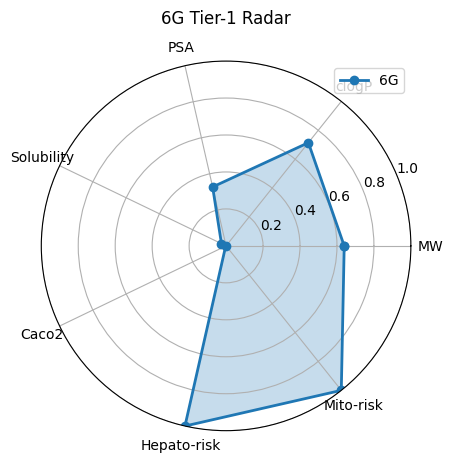

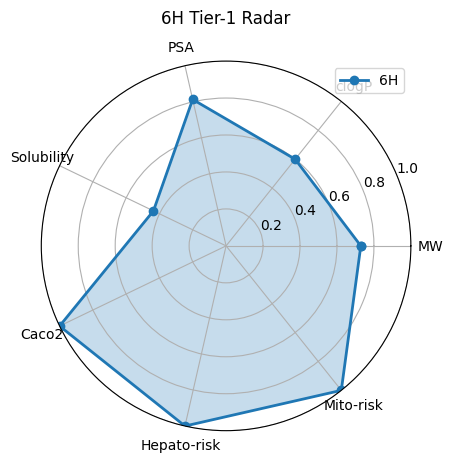


=== TIER 1 & 2 GAP-CLOSURE SUMMARY ===
6G  IC50<100 nM: False  Kp>1: False  Off-target<0.5: False  Mito-safe: False  →  0/4 Tier-1 PASS
6H  IC50<100 nM: True  Kp>1: True  Off-target<0.5: False  Mito-safe: False  →  2/4 Tier-1 PASS


In [ ]:
# ---------- 6. Radar Chart ----------
import matplotlib.pyplot as plt
def radar_card(code):
    df = cards[cards.code==code].iloc[0]
    cats = ['MW','clogP','PSA','Solubility','Caco2','Hepato-risk','Mito-risk']
    vals = [df['MW']/600, df['clogP']/5, df['PSA (Å²)']/140,
            min(df['Solubility (mg/L)']/1000,1), min(df['Caco2']/100,1),
            df['Hepato-risk'], df['Mito-risk']]
    vals += vals[:1]; angles = np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist() + [0]
    ax = plt.subplot(111, projection='polar')
    ax.plot(angles, vals, 'o-', linewidth=2, label=code)
    ax.fill(angles, vals, alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats)
    ax.set_ylim(0,1); ax.set_title(f'{code} Tier-1 Radar', y=1.08)
    plt.legend(); plt.show()

for c in ('6G','6H'): radar_card(c)

# ---------- 7. Gap-closure flags ----------
print('\n=== TIER 1 & 2 GAP-CLOSURE SUMMARY ===')
for c in ('6G','6H'):
    ip, kp = pred[c]
    off_max = off_df.loc[c].max()
    mito_risk = cards[cards.code==c]['Mito-risk'].iloc[0]
    flags = [ip < 100, kp > 1, off_max < 0.5, mito_risk < 0.5]
    print(f"{c}  IC50<100 nM: {flags[0]}  Kp>1: {flags[1]}  Off-target<0.5: {flags[2]}  Mito-safe: {flags[3]}  →  {sum(flags)}/4 Tier-1 PASS")